# Pré-processamento — câncer de mama (maligno vs benigno)

Limpeza, correlação para modelagem, split treino/teste estratificado e pipeline sklearn — com artefato para os notebooks seguintes.
- **Pasta Base:** `src/db/`
- **Arquivo:** `models/breast-cancer-wisconsin-data/data.csv`
- **Figuras:** `src/db/outputs/breast-cancer-wisconsin-data/03-preprocessamento/figures/`
- **Artefato:** `src/db/outputs/breast-cancer-wisconsin-data/03-preprocessamento/artifacts/dados_preprocessados.joblib`
- **Alvo:** coluna `diagnosis` — **M** = maligno (1), **B** = benigno (0)

## 1 - Setup e carga dos dados

In [1]:
# Célula comum (v2) + imports de pré-processamento
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Encontra a raiz do repositório (notebooks em subpastas ou na raiz)
def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/breast-cancer-wisconsin-data"

CAMINHO_CSV = RAIZ / "src/db/models/breast-cancer-wisconsin-data/data.csv"
PASTA_BASE = OUTPUT_BASE / "03-preprocessamento"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [2]:
# Carrega CSV bruto; remove id e coluna vazia do Kaggle
dados = pd.read_csv(CAMINHO_CSV)
dados.columns = dados.columns.str.strip()  # cabeçalho do CSV pode ter espaços extras
dados = dados.drop(columns=["id", "Unnamed: 32"], errors="ignore")

print(f"Arquivo carregado: {CAMINHO_CSV}")
print("Dimensão (linhas, colunas):", dados.shape)
print("Ausentes:", dados.isna().sum().sum())
print("Duplicatas:", dados.duplicated().sum())

display(dados.head())

Arquivo carregado: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\models\breast-cancer-wisconsin-data\data.csv
Dimensão (linhas, colunas): (569, 31)
Ausentes: 0
Duplicatas: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2 - Preparar atributos e rótulo
- **M → 1, B → 0:** maligno é a classe positiva clínica (foco em recall / falso negativo).
- Atributos restantes são features numéricas de imagem (média, erro-padrão e pior valor).

In [3]:
MAPA_ROTULOS = {"M": 1, "B": 0}  # 1 = maligno — classe positiva clínica
COLUNA_ALVO = "diagnosis"

dados_modelagem = dados.copy()
dados_modelagem[COLUNA_ALVO] = dados_modelagem[COLUNA_ALVO].map(MAPA_ROTULOS)

colunas_atributos = [c for c in dados_modelagem.columns if c not in (COLUNA_ALVO)]
atributos = dados_modelagem[colunas_atributos]
rotulo = dados_modelagem[COLUNA_ALVO]

print("Atributos:", len(colunas_atributos))
print("Distribuição do rótulo (0=benigno, 1=maligno):")
print(rotulo.value_counts(normalize=True).rename({0: "benigno", 1: "maligno"}).round(3))

display(rotulo.head())

Atributos: 30
Distribuição do rótulo (0=benigno, 1=maligno):
diagnosis
benigno    0.627
maligno    0.373
Name: proportion, dtype: float64


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

## 3 - Correlação para modelagem

Heatmap entre atributos e o alvo numérico (`maligno`).

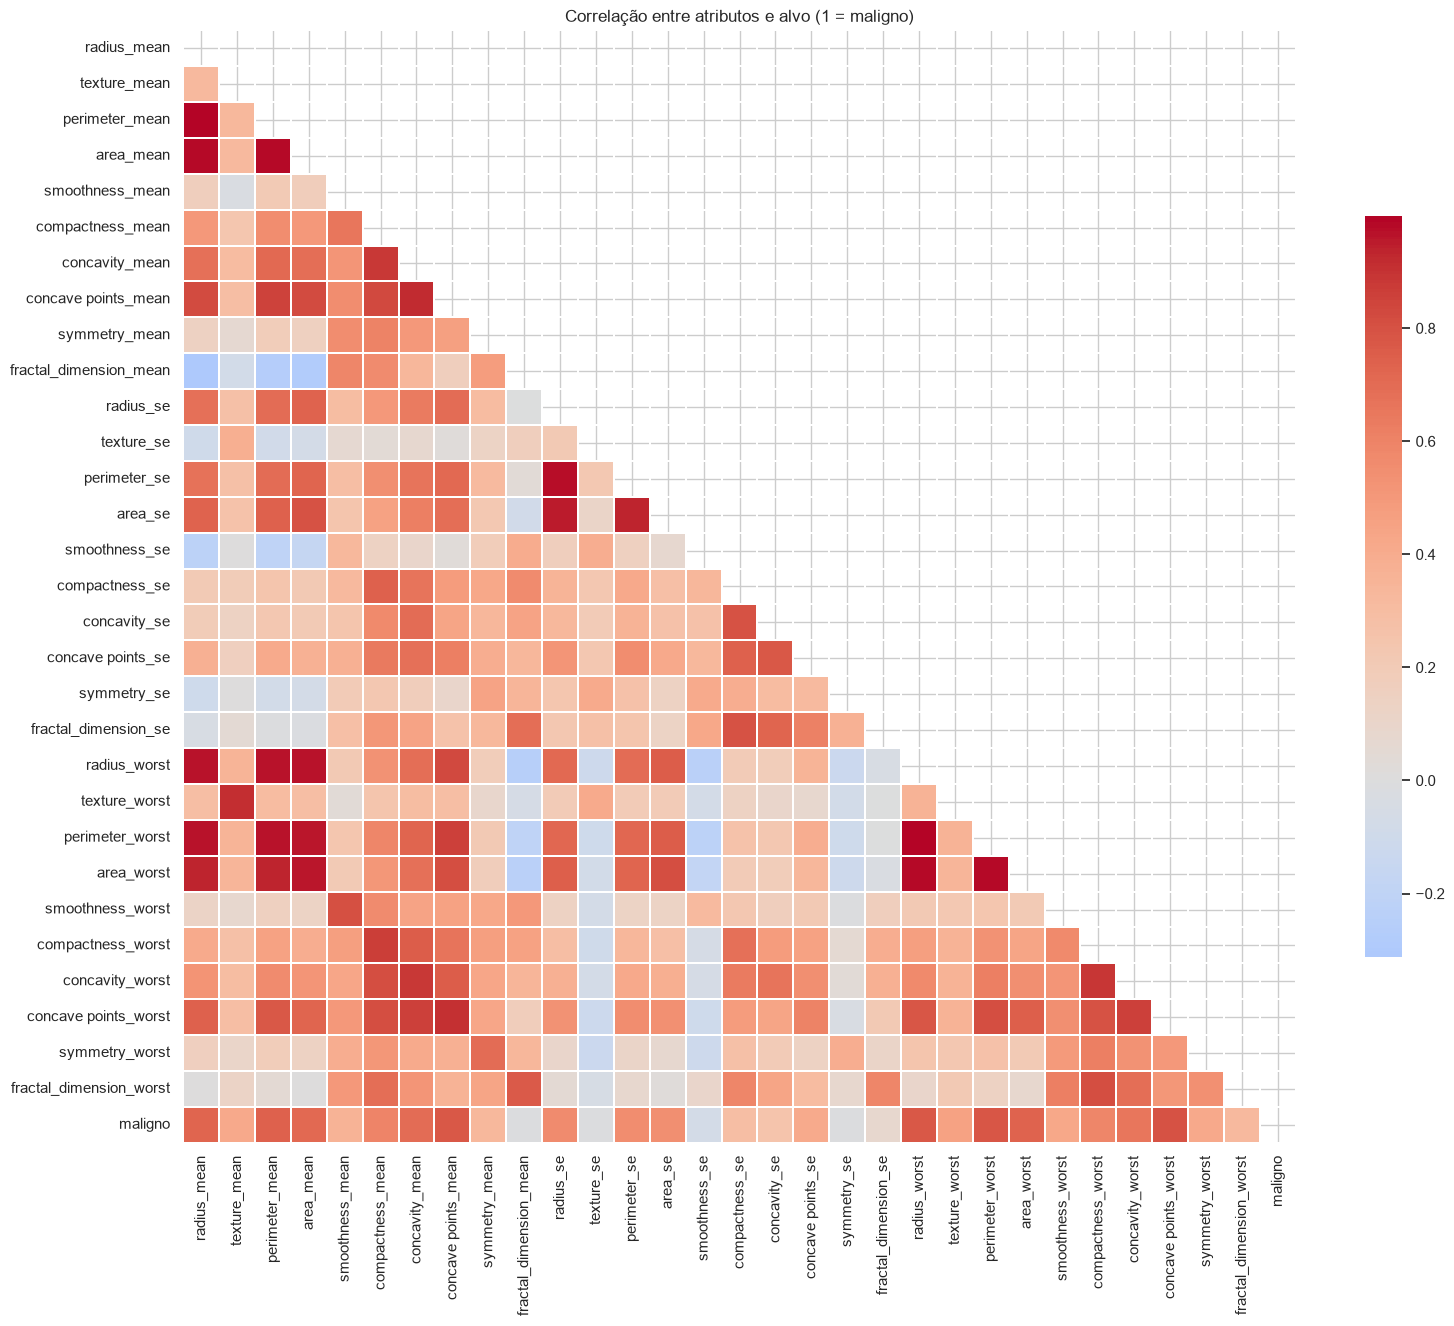

Pares com |r| > 0.9: 21
  radius_mean × perimeter_mean: 0.998
  radius_mean × area_mean: 0.987
  radius_mean × radius_worst: 0.97
  radius_mean × perimeter_worst: 0.965
  radius_mean × area_worst: 0.941
  texture_mean × texture_worst: 0.912
  perimeter_mean × area_mean: 0.987
  perimeter_mean × radius_worst: 0.969
  perimeter_mean × perimeter_worst: 0.97
  perimeter_mean × area_worst: 0.942
  area_mean × radius_worst: 0.963
  area_mean × perimeter_worst: 0.959
  area_mean × area_worst: 0.959
  concavity_mean × concave points_mean: 0.921
  concave points_mean × concave points_worst: 0.91


In [4]:
matriz_corr = atributos.join(rotulo.rename("maligno")).corr()

plt.figure(figsize=(16, 14))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(
    matriz_corr,
    mask=mascara,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.6},
)
plt.title("Correlação entre atributos e alvo (1 = maligno)")
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "05_correlacao_modelagem.png", dpi=150, bbox_inches="tight")
plt.show()

# Pares com |r| > 0.9 — candidatos a redundância
pares_fortes = []
colunas_corr = matriz_corr.columns
for i, col_a in enumerate(colunas_corr):
    for col_b in colunas_corr[i + 1 :]:
        r = matriz_corr.loc[col_a, col_b]
        if abs(r) > 0.9:
            pares_fortes.append((col_a, col_b, round(float(r), 3)))

print(f"Pares com |r| > 0.9: {len(pares_fortes)}")
for col_a, col_b, r in pares_fortes[:15]:
    print(f"  {col_a} × {col_b}: {r}")

**Interpretação:** atributos de tamanho (`radius_*`, `perimeter_*`, `area_*`) e de irregularidade (`concavity_*`, `concave points_*`) correlacionam forte entre si e com o alvo. Isso reforça o padrão da EDA: tumores malignos tendem a ser maiores e com contorno menos regular. Para o modelo, mantemos todos os atributos nesta fase; o preprocessador padroniza escalas sem remover colunas.

## 4 - Split estratificado treino / teste

`stratify=rotulo` mantém a mesma proporção maligno/benigno nos dois conjuntos — importante com classes desbalanceadas (~37% maligno).

In [5]:
SEMENTE = 42
atributos_treino, atributos_teste, rotulo_treino, rotulo_teste = train_test_split(
    atributos,
    rotulo,
    test_size=0.2,
    random_state=SEMENTE,
    stratify=rotulo,  # mesma proporção M/B em treino e teste
)

print("Treino:", atributos_treino.shape, "| Teste:", atributos_teste.shape)
print("Proporção maligno — treino:", round(rotulo_treino.mean(), 3))
print("Proporção maligno — teste:", round(rotulo_teste.mean(), 3))

Treino: (455, 30) | Teste: (114, 30)
Proporção maligno — treino: 0.374
Proporção maligno — teste: 0.368


## 5 - Preprocessador (sem `fit` ainda)

- **Imputação por mediana:** robusta a outliers (embora este dataset quase não tenha ausentes).
- **StandardScaler:** necessário para regressão logística;

PS: Foi instanciado nessa etapa e posteriormente não foi necessario usa-lo. Mantive apenas para manter a organização e possivel uso futuro.

In [6]:
preprocessador = ColumnTransformer([
    ("numericas", Pipeline([
        ("preencher", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler()),  # necessário para regressão logística
    ]), colunas_atributos),
])

print("Preprocessador definido (ainda sem fit):")
print(preprocessador)

Preprocessador definido (ainda sem fit):
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('preencher',
                                                  SimpleImputer(strategy='median')),
                                                 ('padronizar',
                                                  StandardScaler())]),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se'

## 6 - Salvar artefato para o notebook 04

In [7]:
joblib.dump(
    {
        "atributos_treino": atributos_treino,
        "atributos_teste": atributos_teste,
        "rotulo_treino": rotulo_treino,
        "rotulo_teste": rotulo_teste,
        "colunas_atributos": colunas_atributos,
        "preprocessador": preprocessador,
        "semente": SEMENTE,
    },
    PASTA_ARTEFATOS / "dados_preprocessados.joblib",
)
print("Artefato salvo — use no notebook 04")
print(PASTA_ARTEFATOS / "dados_preprocessados.joblib")

Artefato salvo — use no notebook 04
E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\03-preprocessamento\artifacts\dados_preprocessados.joblib


## 7 - Validação

Essa validação é importante para garantir que as proximas etapas irão receber os dados necessários conforme mapeados.

In [8]:
assert (PASTA_ARTEFATOS / "dados_preprocessados.joblib").exists()
assert (PASTA_FIGURAS / "05_correlacao_modelagem.png").exists()

pacote = joblib.load(PASTA_ARTEFATOS / "dados_preprocessados.joblib")
assert set(pacote.keys()) >= {
    "atributos_treino",
    "atributos_teste",
    "rotulo_treino",
    "rotulo_teste",
    "colunas_atributos",
    "preprocessador",
    "semente",
}
assert len(pacote["colunas_atributos"]) == 30
assert pacote["atributos_treino"].shape[0] + pacote["atributos_teste"].shape[0] == len(atributos)

print("Validação OK")
print("Figura:", PASTA_FIGURAS / "05_correlacao_modelagem.png")
print("Artefato:", PASTA_ARTEFATOS / "dados_preprocessados.joblib")

Validação OK
Figura: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\03-preprocessamento\figures\05_correlacao_modelagem.png
Artefato: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\breast-cancer-wisconsin-data\03-preprocessamento\artifacts\dados_preprocessados.joblib
